# FDSI benchmark: dataset

The FDSI benchmark is a synthetic HD-EMG dataset generated with MUniverse's linear muscle
model, simulating a single forearm muscle (`FDSI`, flexion-extension) driven by 5 kinematic
conditions across 5 subjects, each with its own simulated motor-unit pool. Every noiseless
recording is re-used at 4 SNR levels, giving 5 subjects x 5 conditions x 4 SNR levels = 100
noisy recordings (+ 25 noiseless originals), each with a matching ground-truth spike train.
This is a read-only tour of that raw data -- the units and calibration/adaptation cache the
other `notebooks/fdsi_benchmark/` notebooks build on top of it (starting with
`01_calibration.ipynb`) live under `FDSI_ROOT/calibration/` and `FDSI_ROOT/adaptation/`, not
here.

## Config

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../..')          # package root
sys.path.insert(0, str(Path.cwd()))  # this notebook's own directory, for fdsi_common

import numpy as np
import pandas as pd
import yaml

import fdsi_common as fc

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

FDSI_ROOT = Path(grid['fdsi_root'])
DATA_DIR = FDSI_ROOT / 'data'

FS = grid['fs']
CAL_DURATION_S = grid['cal_duration_s']  # calibration window used downstream == each recording's isometric bookend

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']

print(f'{len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} noisy recordings '
      f'(+ {len(SUBJECTS) * len(CONDITIONS)} noiseless originals)')

5 subjects x 5 conditions x 4 SNR levels = 100 noisy recordings (+ 25 noiseless originals)


## Recording metadata

Every clean recording carries a `metadata.json` describing the muscle model and grid it was
simulated with. Some fields are fixed for the whole benchmark (channel count, sampling rate,
target contraction effort); others -- the motor-unit pool -- are drawn once per subject
(`subject_seed`) and shared across that subject's 5 conditions. Both are read directly off
disk below rather than assumed, and checked for the constancy claimed above.

In [2]:
# Fields that should be identical across every recording in the benchmark
const_fields = ['n_channels', 'fs', 'effort_level_pct', 'crosstalk_threshold', 'movement_dof', 'muscle']
const_vals = {field: set() for field in const_fields}
for sub in SUBJECTS:
    for cond in CONDITIONS:
        meta = fc.load_recording_metadata(DATA_DIR, sub, cond)
        for field in const_fields:
            const_vals[field].add(meta[field])

assert all(len(vals) == 1 for vals in const_vals.values()), \
    f'expected these fields constant across the benchmark, got {const_vals}'
const = {field: vals.pop() for field, vals in const_vals.items()}
const

{'n_channels': 100,
 'fs': 2048,
 'effort_level_pct': 15,
 'crosstalk_threshold': 0.9,
 'movement_dof': 'Flexion-Extension',
 'muscle': 'FDSI'}

In [3]:
# Motor-unit pool, drawn once per subject and shared across its 5 conditions
mu_rows = []
for sub in SUBJECTS:
    per_cond = [fc.load_recording_metadata(DATA_DIR, sub, cond) for cond in CONDITIONS]
    pool = {(m['n_motor_units'], m['n_active_mus'], m['fibre_density']) for m in per_cond}
    assert len(pool) == 1, f'{sub}: motor-unit pool differs across conditions, expected one draw per subject'
    n_mus, n_active, fibre_density = pool.pop()
    mu_rows.append({'subject': sub, 'subject_seed': per_cond[0]['subject_seed'],
                     'n_motor_units': n_mus, 'n_active_mus': n_active, 'fibre_density': fibre_density})
df_mu = pd.DataFrame(mu_rows).set_index('subject')
df_mu

,subject_seed,n_motor_units,n_active_mus,fibre_density
subject,,,,
sub-01,0,64,39,194
sub-02,1,57,34,187
sub-03,2,87,53,190
sub-04,3,91,55,174
sub-05,4,74,45,196


## Conditions

One staircase and four triangular ramps (differing only in ramp speed), each bookended by a
`CAL_DURATION_S` s isometric hold -- the calibration window every downstream notebook
calibrates `CBSS` on.

In [4]:
cond_rows = []
for cond in CONDITIONS:
    meta = fc.load_recording_metadata(DATA_DIR, SUBJECTS[0], cond)
    cond_rows.append({
        'condition':        cond,
        'type':             meta['condition_type'],
        'duration_s':       meta['total_duration_s'],
        'peak_angle_deg':   meta['peak_angle_deg'],
        'ramp_duration_s':  meta.get('ramp_duration_s'),
        'n_reps':           meta.get('n_reps'),
        'step_deg':         meta.get('step_deg'),
        'hold_duration_s':  meta.get('hold_duration_s'),
    })
df_cond = pd.DataFrame(cond_rows).set_index('condition')
df_cond

,type,duration_s,peak_angle_deg,ramp_duration_s,n_reps,step_deg,hold_duration_s
condition,,,,,,,
staircase,staircase,125.0,40.0,10.0,NaN,10.0,5.0
triangular-ramp40s,triangular,90.0,40.0,40.0,1.0,NaN,NaN
triangular-ramp20s,triangular,90.0,40.0,20.0,2.0,NaN,NaN
triangular-ramp10s,triangular,90.0,40.0,10.0,4.0,NaN,NaN
triangular-ramp5s,triangular,90.0,40.0,5.0,8.0,NaN,NaN


## Angle profile and contraction level

Each condition drives a different wrist-angle trajectory (0-40 deg), but the target
contraction effort is held **fixed** at `effort_level_pct` % MVC for the entire recording --
it does not track the angle. The angle trace itself is identical across subjects (only the
motor-unit pool differs), so one subject is representative of all 5.

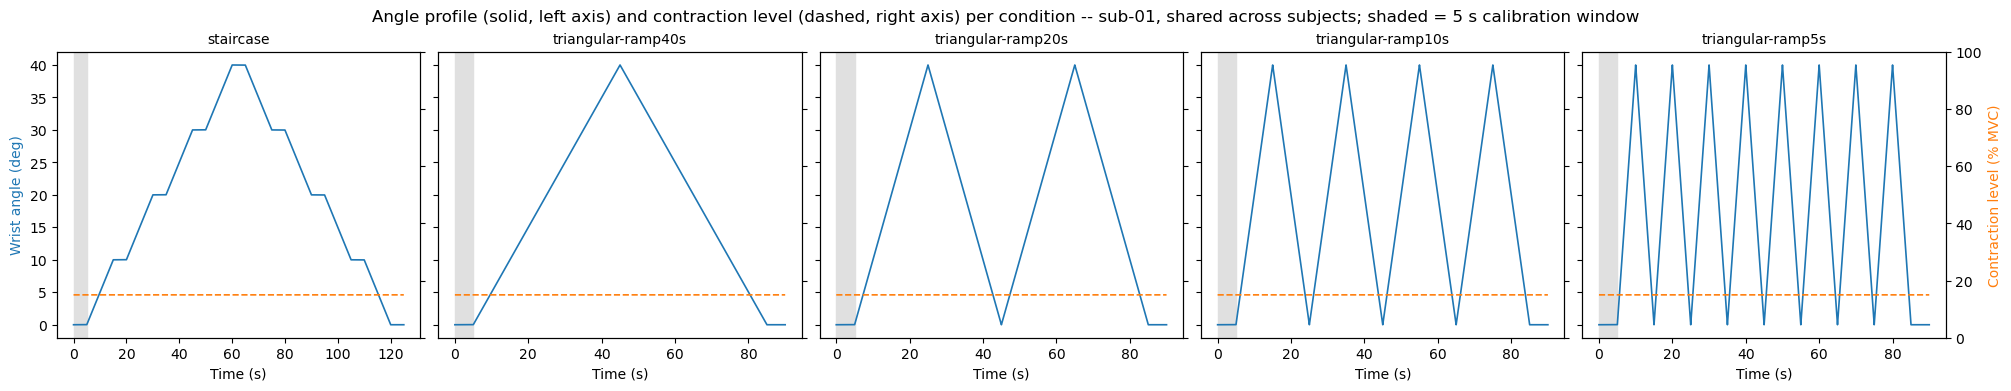

In [5]:
import matplotlib.pyplot as plt

sub = SUBJECTS[0]

# Angle profiles are shared across subjects -- confirm before treating one subject as representative
ref_angle = fc.load_angle_profile(DATA_DIR, sub, CONDITIONS[0])
for other_sub in SUBJECTS[1:]:
    assert np.array_equal(fc.load_angle_profile(DATA_DIR, other_sub, CONDITIONS[0]), ref_angle)

fig, axs = plt.subplots(1, len(CONDITIONS), figsize=(20, 3.8), sharey=True, layout='constrained')
for i, (ax, cond) in enumerate(zip(axs, CONDITIONS)):
    angle = fc.load_angle_profile(DATA_DIR, sub, cond)
    effort = fc.load_effort_profile(DATA_DIR, sub, cond)
    t = np.arange(len(angle)) / FS

    ax.axvspan(0, CAL_DURATION_S, color='0.88', zorder=0)
    ax.plot(t, angle, color='C0', lw=1.2)
    ax.set_title(cond, fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.tick_params(axis='y', labelleft=(i == 0))

    ax_r = ax.twinx()
    ax_r.plot(t, effort * 100, color='C1', ls='--', lw=1.2)
    ax_r.set_ylim(0, 100)
    ax_r.tick_params(axis='y', labelright=(i == len(CONDITIONS) - 1))
    if i == len(CONDITIONS) - 1:
        ax_r.set_ylabel('Contraction level (% MVC)', color='C1')

axs[0].set_ylabel('Wrist angle (deg)', color='C0')
fig.suptitle(f'Angle profile (solid, left axis) and contraction level (dashed, right axis) per condition '
             f'-- {sub}, shared across subjects; shaded = {int(CAL_DURATION_S)} s calibration window')
plt.show()

## Noise levels (SNR)

Each noiseless recording is re-used at 4 target SNR levels (30/25/20/15 dB), with per-channel
noise power calibrated to hit that target exactly -- checked below against every recording's
`noise_metadata.json` rather than assumed.

In [6]:
max_diff_db = 0.0
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            noise_meta = fc.load_noise_metadata(DATA_DIR, sub, cond, snr)
            max_diff_db = max(max_diff_db, abs(noise_meta['snr_db_actual'] - noise_meta['snr_db_target']))

n_checked = len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)
print(f'Checked {n_checked} noisy recordings: max |realised - target SNR| = {max_diff_db:.4f} dB')

Checked 100 noisy recordings: max |realised - target SNR| = 0.0100 dB


The same 1 s EMG snippet, one central grid channel, clean vs. each noise level (overlaid so
the injected noise reads as a direct deviation from the clean trace, rather than something to
compare by eye across separate panels). Each panel's measured SNR (from this one channel/window)
is annotated alongside its target, for a sanity check consistent with the whole-recording check
above.

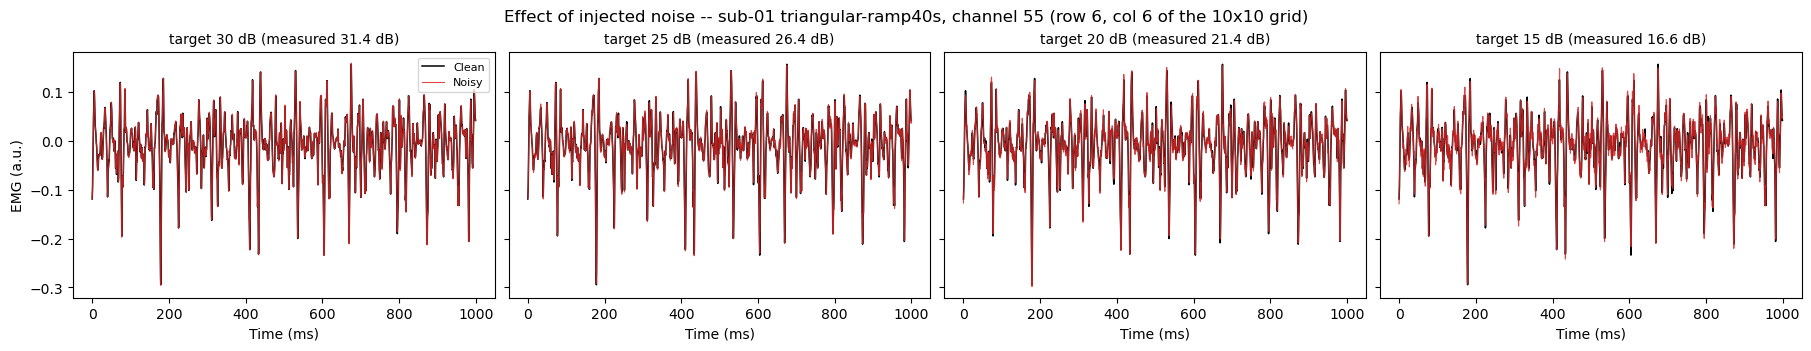

In [7]:
sub, cond = SUBJECTS[0], CONDITIONS[1]  # triangular-ramp40s

meta = fc.load_recording_metadata(DATA_DIR, sub, cond)
row_idx = meta['n_rows'] // 2
col_idx = meta['center_column'] - meta['selected_columns'][0]
channel = row_idx * meta['n_cols'] + col_idx

t0_s, win_s = 30.0, 1.0
i0, i1 = int(t0_s * FS), int((t0_s + win_s) * FS)
t_ms = (np.arange(i0, i1) - i0) / FS * 1000

clean = fc.load_clean_emg(DATA_DIR, sub, cond)[i0:i1, channel]
clean_rms = np.sqrt(np.mean(clean ** 2))

fig, axs = plt.subplots(1, len(SNR_LEVELS), figsize=(18, 3.4), sharex=True, sharey=True, layout='constrained')
for ax, snr in zip(axs, SNR_LEVELS):
    noisy = fc.load_raw_emg(DATA_DIR, sub, cond, snr)[i0:i1, channel]
    noise_rms = np.sqrt(np.mean((noisy - clean) ** 2))
    measured_db = 10 * np.log10((clean_rms / noise_rms) ** 2)

    ax.plot(t_ms, clean, color='k', lw=1.1, label='Clean')
    ax.plot(t_ms, noisy, color='C3', lw=0.8, alpha=0.85, label='Noisy')
    ax.set_title(f'target {snr} dB (measured {measured_db:.1f} dB)', fontsize=10)
    ax.set_xlabel('Time (ms)')

axs[0].set_ylabel('EMG (a.u.)')
axs[0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'Effect of injected noise -- {sub} {cond}, channel {channel} '
             f'(row {row_idx + 1}, col {col_idx + 1} of the {meta["n_rows"]}x{meta["n_cols"]} grid)')
plt.show()

See `01_calibration.ipynb` for how these recordings are turned into per-recording
motor-unit decompositions.